# Wrinkle Segmentation with Simple U-Net

In [1]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", device)

Device: cpu


In [2]:
# Dataset paths
MASK_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks")


# For a baseline experiment, which involves only augmentations
IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles")

# # For a ROI experiment, which involves extraction of facial ROI region
# IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi")

# # For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess")


# Training settings
IMG_SIZE = 1024
BATCH_SIZE = 2
NUM_EPOCHS = 45
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
THRESHOLD = 0.5

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.80, 1.25), p=0.50):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma)


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.20):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius))


class WrinkleSegDataset(Dataset):
    def __init__(self, pairs, img_size=1024, train=False):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015,
            ),
            RandomGamma(),
            RandomGaussianBlur(),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = TF.resize(img, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
            img = self.color_aug(img)

        img = self.normalize(TF.to_tensor(img))
        mask = (TF.to_tensor(mask) > 0.5).float()

        return img, mask

In [4]:
def find_image_mask_pairs(img_dir, mask_dir):
    image_paths = sorted(img_dir.glob("*.png"))
    pairs = []

    for img_path in image_paths:
        mask_path = mask_dir / img_path.name
        if mask_path.exists():
            pairs.append((img_path, mask_path))
        else:
            print(f"Mask not found for {img_path.name}")

    print(f"Recovered {len(pairs)} image-mask pairs.")
    return pairs


pairs = find_image_mask_pairs(IMG_DIR, MASK_DIR)
pairs[:3]

Recovered 1000 image-mask pairs.


[(PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00001.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00001.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00011.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00011.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00016.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00016.png'))]

In [5]:
def denormalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img * std + mean, 0, 1)


def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))
    batch_size = imgs.shape[0]

    fig, axes = plt.subplots(2, batch_size, figsize=(3 * batch_size, 6))
    if batch_size == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(batch_size):
        img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        mask = masks[i, 0].numpy()

        axes[0, i].imshow(img)
        axes[0, i].set_title("Image")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title("Mask")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

train/val/test samples: 800, 100, 100
train/val/test batches: 400, 50, 50


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


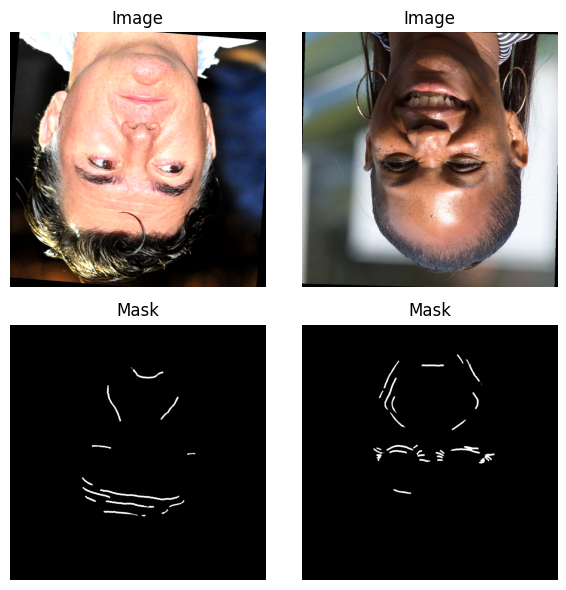

In [6]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

train_dataset = WrinkleSegDataset(train_pairs, img_size=IMG_SIZE, train=True)
val_dataset = WrinkleSegDataset(val_pairs, img_size=IMG_SIZE, train=False)
test_dataset = WrinkleSegDataset(test_pairs, img_size=IMG_SIZE, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"train/val/test samples: {len(train_dataset)}, {len(val_dataset)}, {len(test_dataset)}")
print(f"train/val/test batches: {len(train_loader)}, {len(val_loader)}, {len(test_loader)}")

show_batch_with_masks(train_loader)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, features[0])
        self.enc2 = DownBlock(features[0], features[1])
        self.enc3 = DownBlock(features[1], features[2])
        self.enc4 = DownBlock(features[2], features[3])

        self.bottleneck = DownBlock(features[3], features[3] * 2)

        self.dec4 = UpBlock(features[3] * 2, features[3], features[3])
        self.dec3 = UpBlock(features[3], features[2], features[2])
        self.dec2 = UpBlock(features[2], features[1], features[1])
        self.dec1 = UpBlock(features[1], features[0], features[0])

        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)

        x = self.bottleneck(s4)

        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.out_conv(x)

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    probs = probs.flatten(1)
    targets = targets.flatten(1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + smooth)
    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2.0 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def pixel_metrics(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()

    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    return accuracy, precision, recall

In [ ]:
def train_one_epoch(model, loader, optimizer, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs}", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)
        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks, threshold=THRESHOLD)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        pbar.set_postfix(loss=loss.item(), dice=dice, iou=iou)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    total_accuracy = 0.0
    total_precision = 0.0
    total_recall = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)
        iou, dice = batch_iou_dice(logits, masks, threshold=threshold)
        accuracy, precision, recall = pixel_metrics(logits, masks, threshold=threshold)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice
        total_accuracy += accuracy
        total_precision += precision
        total_recall += recall

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": total_accuracy / n,
        "precision": total_precision / n,
        "recall": total_recall / n,
    }

In [ ]:
model = SimpleUNet(
    in_channels=3,
    out_channels=1,
    features=(64, 128, 256, 512),
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_dice = -1.0
history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device, epoch, NUM_EPOCHS)
    val_metrics = evaluate(model, val_loader, device, threshold=THRESHOLD)
    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"train_loss={train_metrics['loss']:.4f}, train_iou={train_metrics['iou']:.4f}, train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, val_iou={val_metrics['iou']:.4f}, val_dice={val_metrics['dice']:.4f}, "
        f"val_precision={val_metrics['precision']:.4f}, val_recall={val_metrics['recall']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "best_simple_unet.pth")
        print("Saved best model.")

In [ ]:
def plot_history(history):
    for metric in ["loss", "iou", "dice"]:
        plt.figure(figsize=(7, 4))
        plt.plot(history[f"train_{metric}"], label=f"train_{metric}")
        plt.plot(history[f"val_{metric}"], label=f"val_{metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


plot_history(history)

In [ ]:
@torch.no_grad()
def predict_batch(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), logits.cpu(), preds.cpu(), probs.cpu()


def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred_flat = pred.flatten()
    target_flat = target.flatten()

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2.0 * intersection + eps) / (pred_flat.sum() + target_flat.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def show_predictions_overlay(imgs, masks, logits, n=4, threshold=0.5, alpha=0.45):
    n = min(n, imgs.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        gt = masks[i, 0].cpu().numpy()

        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)
        pred = (prob > threshold).astype(np.float32)
        overlay = make_error_overlay(img, pred, gt, alpha=alpha)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice={dice:.3f}, IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay\nGreen=TP, Red=FP, Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
model.load_state_dict(torch.load("best_simple_unet.pth", map_location=device))
test_metrics = evaluate(model, test_loader, device, threshold=THRESHOLD)
test_metrics

In [ ]:
imgs, masks, logits, preds, probs = predict_batch(model, test_loader, device, threshold=THRESHOLD)
show_predictions_overlay(imgs, masks, logits, n=4, threshold=THRESHOLD)